In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

df = pd.read_csv('Reviews_sentiment.csv')
print(df.shape)
print(df.columns.tolist())

(364163, 18)
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'review_length', 'helpfulness_ratio', 'Year', 'cleaned_text', 'cleaned_summary', 'sentiment', 'vader_sentiment', 'vader_binary']


In [3]:
df['cleaned_text'] = df['cleaned_text'].fillna('')
df = df[df['cleaned_text'].str.strip() != '']

vectorizer = CountVectorizer(
    max_features=15000,   # back to 15K
    min_df=5,
    max_df=0.90
)

doc_term_matrix = vectorizer.fit_transform(df['cleaned_text'])
print(f"Document-Term Matrix shape: {doc_term_matrix.shape}")
print(f"Matrix type: {type(doc_term_matrix)}")
print(f"Stored elements: {doc_term_matrix.nnz:,}")

Document-Term Matrix shape: (364163, 15000)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Stored elements: 10,430,414


In [4]:
lda = LatentDirichletAllocation(
    n_components=8,
    random_state=42,
    learning_method='online',  # online = processes in batches
    batch_size=2048,           # processes 2048 docs at a time
    max_iter=5,
    n_jobs=1
)

# Train in batches manually
batch_size = 2048
n_samples = doc_term_matrix.shape[0]

for i, start in enumerate(range(0, n_samples, batch_size)):
    end = min(start + batch_size, n_samples)
    batch = doc_term_matrix[start:end]
    lda.partial_fit(batch)
    if i % 20 == 0:
        print(f"Processed {end}/{n_samples} reviews...")

print("LDA model trained successfully!")

Processed 2048/364163 reviews...
Processed 43008/364163 reviews...
Processed 83968/364163 reviews...
Processed 124928/364163 reviews...
Processed 165888/364163 reviews...
Processed 206848/364163 reviews...
Processed 247808/364163 reviews...
Processed 288768/364163 reviews...
Processed 329728/364163 reviews...
LDA model trained successfully!


In [5]:
# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Print top 15 words per topic
def print_topics(model, feature_names, n_top_words=15):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words-1:-1]]
        print(f"\nTopic {topic_idx + 1}:")
        print(" | ".join(top_words))

print_topics(lda, feature_names)


Topic 1:
chocolate | like | good | great | taste | sugar | eat | snack | love | cookies | butter | cereal | sweet | bars | calories

Topic 2:
food | dog | dogs | cat | treats | cats | loves | eat | love | like | product | old | good | formula | treat

Topic 3:
product | would | like | box | bag | time | didnt | could | work | bad | know | hair | bought | away | package

Topic 4:
tea | drink | water | taste | like | flavor | good | green | teas | great | sugar | love | drinking | sweet | tastes

Topic 5:
like | taste | flavor | good | tried | mix | best | flavors | try | bread | love | juice | syrup | candy | product

Topic 6:
like | sauce | flavor | oil | good | taste | add | hot | salt | great | rice | coconut | water | chicken | soup

Topic 7:
amazon | price | product | great | find | store | good | buy | order | love | time | local | shipping | stores | ordered

Topic 8:
coffee | like | cup | flavor | good | taste | beans | vanilla | great | roast | dark | best | strong | tried | l

In [6]:
# Define topic labels based on interpretation
topic_labels = {
    0: 'Snacks & Sweet Foods',
    1: 'Pet Food',
    2: 'Packaging & Product Issues',
    3: 'Tea & Beverages',
    4: 'Pantry & Cooking Ingredients',
    5: 'Cooking & Condiments',
    6: 'Shopping & Pricing',
    7: 'Coffee'
}

# Assign dominant topic to each review
doc_topic_matrix = lda.transform(doc_term_matrix)
df['dominant_topic'] = doc_topic_matrix.argmax(axis=1)
df['topic_label'] = df['dominant_topic'].map(topic_labels)

# Check distribution
print(df['topic_label'].value_counts())

topic_label
Shopping & Pricing              74495
Snacks & Sweet Foods            54950
Cooking & Condiments            48544
Packaging & Product Issues      43001
Pet Food                        39204
Tea & Beverages                 36920
Pantry & Cooking Ingredients    33822
Coffee                          33227
Name: count, dtype: int64


"Shopping & Pricing is the single largest topic (20.5%) — suggesting Amazon food customers are highly price-conscious and value-driven, making competitive pricing the most discussed aspect of the food shopping experience."


"43,001 reviews relate to Packaging & Product Issues — representing a significant operational risk area requiring immediate attention from product and logistics teams."

                              total  positive_count  positive_rate  \
topic_label                                                          
Packaging & Product Issues    43001           25424          59.12   
Pantry & Cooking Ingredients  33822           26228          77.55   
Coffee                        33227           28467          85.67   
Pet Food                      39204           33789          86.19   
Shopping & Pricing            74495           66124          88.76   
Tea & Beverages               36920           32901          89.11   
Cooking & Condiments          48544           43648          89.91   
Snacks & Sweet Foods          54950           50474          91.85   

                              negative_rate  
topic_label                                  
Packaging & Product Issues            40.88  
Pantry & Cooking Ingredients          22.45  
Coffee                                14.33  
Pet Food                              13.81  
Shopping & Pricing     

C:\Users\pragy\AppData\Local\Temp\ipykernel_9252\593185275.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


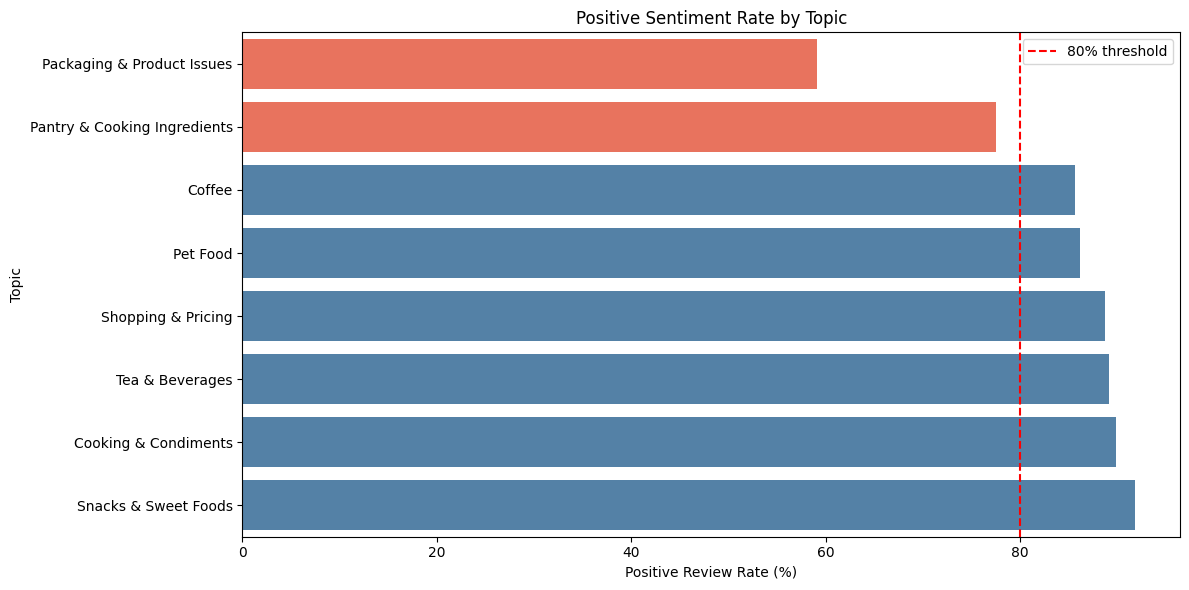

In [7]:
# Calculate sentiment rate per topic
topic_sentiment = df.groupby('topic_label')['sentiment'].agg(
    total='count',
    positive_count='sum'
)
topic_sentiment['positive_rate'] = (
    topic_sentiment['positive_count'] / topic_sentiment['total'] * 100
).round(2)
topic_sentiment['negative_rate'] = (
    100 - topic_sentiment['positive_rate']
).round(2)
topic_sentiment = topic_sentiment.sort_values('positive_rate')

print(topic_sentiment)

# Visualise
plt.figure(figsize=(12, 6))
colors = ['tomato' if x < 80 else 'steelblue' for x in topic_sentiment['positive_rate']]
sns.barplot(
    x=topic_sentiment['positive_rate'],
    y=topic_sentiment.index,
    palette=colors
)
plt.title('Positive Sentiment Rate by Topic')
plt.xlabel('Positive Review Rate (%)')
plt.ylabel('Topic')
plt.axvline(x=80, color='red', linestyle='--', label='80% threshold')
plt.legend()
plt.tight_layout()
plt.show()

Key Business Insights
🚨 Packaging is a crisis

"Packaging & Product Issues has the highest negative rate at 40.88% — nearly 1 in 2 customers who discuss packaging are unhappy. With 43,001 reviews in this topic, this represents approximately 17,577 dissatisfied customers — a significant operational problem requiring immediate attention."

⚠️ Pantry ingredients underperforming

"Pantry & Cooking Ingredients has a 22.45% negative rate — more than double the average across other food categories — suggesting quality consistency issues in staple grocery items."

✅ Snacks are the star

"Snacks & Sweet Foods leads all categories with 91.85% positive sentiment — the highest satisfaction rate across all 8 topics, suggesting this is Amazon's strongest food category."

☕ Coffee has room to improve

"Despite being a dedicated enthusiast category, Coffee shows a 14.33% negative rate — higher than Tea (10.89%) — indicating coffee buyers have higher expectations and are harder to satisfy."

C:\Users\pragy\AppData\Local\Temp\ipykernel_9252\3531877035.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_counts.values, y=topic_counts.index, palette=colors)


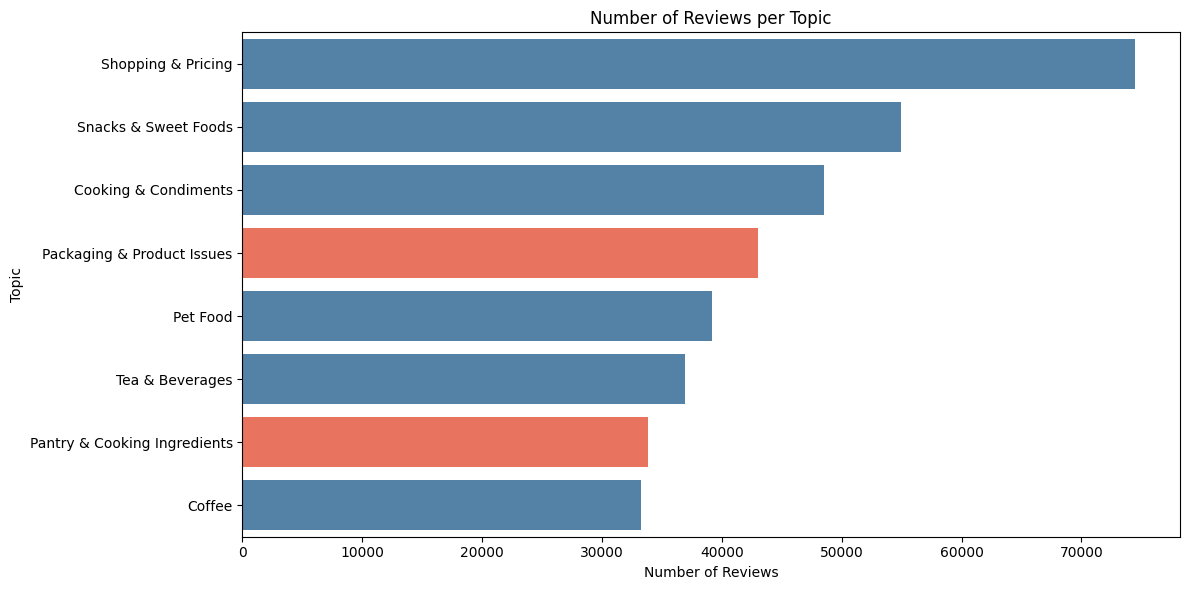

In [8]:
plt.figure(figsize=(12, 6))
topic_counts = df['topic_label'].value_counts()
colors = ['tomato' if label in ['Packaging & Product Issues', 
          'Pantry & Cooking Ingredients'] else 'steelblue' 
          for label in topic_counts.index]

sns.barplot(x=topic_counts.values, y=topic_counts.index, palette=colors)
plt.title('Number of Reviews per Topic')
plt.xlabel('Number of Reviews')
plt.ylabel('Topic')
plt.tight_layout()
plt.show()

What This Chart Communicates
The red bars tell the story instantly:

Packaging & Product Issues — 4th largest topic by volume AND the worst sentiment. High volume + high negativity = biggest business problem
Pantry & Cooking Ingredients — smaller volume but still flagged red

The combination of both charts together is powerful:

Chart 6 shows how bad the sentiment is per topic
Chart 7 shows how many reviews each topic has

Together they prioritize where a business should focus:

Packaging first (large volume + worst sentiment), Pantry second

In [10]:
import pickle
import os

os.makedirs('../outputs', exist_ok=True)

# Save LDA model and vectorizer
with open('../outputs/lda_model.pkl', 'wb') as f:
    pickle.dump(lda, f)

with open('../outputs/lda_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Save topic summary
topic_sentiment.to_csv('../outputs/topic_sentiment_summary.csv')

# Save updated dataframe
df.to_csv('Reviews_topics.csv', index=False)

print("All saved successfully!")
print(df.shape)

All saved successfully!
(364163, 20)
